In [3]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging/deep_hedging


In [4]:
import numpy as np
import math
from src.models.gbm import simulate_gbm

In [6]:
# 30 trading days

S0 = 100.0
sigma = 0.20
T = 30 / 252
n_steps = 30
n_paths = 100_000

paths = simulate_gbm(
    S0=S0,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=123
)

print(paths.shape)

(100000, 31)


In [7]:
assert np.all(paths[:, 0] == S0)
assert np.all(paths > 0)

terminal_prices = paths[:, -1]
print(terminal_prices.mean())  # should be approx S0

100.02153466337425


In [8]:
theoretical_std = S0 * np.sqrt(np.exp(sigma**2 * T) - 1)

empirical_std = paths[:, -1].std()

print("theoretical:", theoretical_std)
print("simulated:  ", empirical_std)

theoretical: 6.908878815297882
simulated:   6.87632429753303


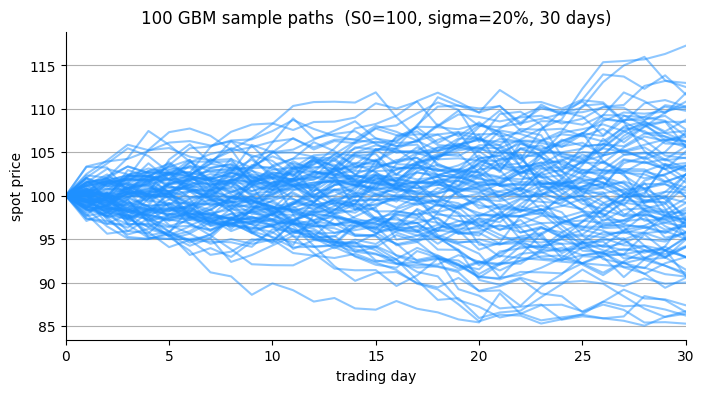

In [31]:
import matplotlib.pyplot as plt

sample_paths = 100

t = np.linspace(0, T, n_steps + 1) * 252  # x-axis in trading days

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(t, paths[:sample_paths].T, color="dodgerblue", alpha=0.5)
ax.axhline(S0, color="#8a8f98", linewidth=1, linestyle="--", zorder=0)

ax.set_title(f"{sample_paths} GBM sample paths  (S0={S0:.0f}, sigma={sigma:.0%}, {n_steps} days)")
ax.set_xlabel("trading day")
ax.set_ylabel("spot price")
ax.set_xlim(0, t[-1])
ax.grid(axis="y")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

plt.show()